# Tahap 2 � Full Fine-Tuning IndoBERT untuk Emotion Classification
Tujuan dari notebook ini adalah melakukan full fine-tuning model IndoBERT pada dataset PRDECT-ID. Seluruh parameter model akan di-update (trainable) untuk mendapatkan representasi emosi yang optimal. Hasil eksperimen mencakup metrik evaluasi, visualisasi, dan analisis kesalahan (error analysis).

## 1. Configuration & Setup
Mendefinisikan parameter eksperimen dan mengatur seed untuk reproducibility.

In [3]:
import os
import random
import json
import time
import math
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

# --- Reproducibility ---
RANDOM_STATE = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

# --- Hyperparameters ---
MODEL_NAME = "indobenchmark/indobert-base-p2"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
PATIENCE = 3
NUM_LABELS = 2  # PIVOT: Klasifikasi Biner Sentimen (Positive vs Negative)
WEIGHT_DECAY = 0.02
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.1
CLASSIFIER_DROPOUT = 0.3
FREEZE_LAYERS = 6  # Freeze the bottom 6 layers to prevent overfitting
LEARNING_RATE = 3e-5
# Learning rate experiments
LR_EXPERIMENTS = [5e-6, 1e-5, 2e-5, 3e-5]
SELECTED_LR = 2e-5

# --- Path Configuration ---
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab. Mounting Drive...")
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/xai_lime_vs_shap"
else:
    print("Running locally.")
    BASE_PATH = "."

TRAIN_DATA_PATH = f"{BASE_PATH}/data/processed/prdect_train.csv"
TEST_DATA_PATH = f"{BASE_PATH}/data/processed/prdect_test.csv"
MAPPING_PATH = f"{BASE_PATH}/data/processed/prdect_label_map.json"
OUTPUT_DIR = f"{BASE_PATH}/outputs/finetuning_indobert"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/model", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/reports", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/tokenizer", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {DEVICE}")
print(f"Model name : {MODEL_NAME}")

# --- Label Mapping Loading ---
if not os.path.exists(MAPPING_PATH):
    MAPPING_PATH = f"{BASE_PATH}/data/processed/prdect_label_map.json"

if os.path.exists(MAPPING_PATH):
    with open(MAPPING_PATH, 'r') as f:
        mapping_data = json.load(f)
    LABEL_MAP = mapping_data.get('label2id', {'negative': 0, 'positive': 1})
    LABEL_MAP = {k.lower().strip(): int(v) for k, v in LABEL_MAP.items()}
    ID2LABEL = {int(k): v.lower().strip() for k, v in mapping_data.get('id2label', {'0': 'negative', '1': 'positive'}).items()}
else:
    LABEL_MAP = {'negative': 0, 'positive': 1}
    ID2LABEL = {0: 'negative', 1: 'positive'}

LABEL_ORDER = [ID2LABEL[i] for i in sorted(ID2LABEL.keys())]
EMOTION_MAP = LABEL_MAP
ID2EMOTION = ID2LABEL

Running in Google Colab. Mounting Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device used: cuda
Model name : indobenchmark/indobert-base-p2


## 2. Load Processed Dataset

In [4]:
df_train = pd.read_csv(TRAIN_DATA_PATH)
df_test = pd.read_csv(TEST_DATA_PATH)

with open(MAPPING_PATH, 'r') as f:
    label_mapping = json.load(f)

print(f"Train samples: {len(df_train)}")
print(f"Test samples : {len(df_test)}")
print("-" * 30)
print("Label Mapping:")
print(label_mapping)

# Normalize schema from preprocessing output
text_column = 'review_clean' if 'review_clean' in df_train.columns else 'Customer Review'
label_name_column = 'emotion_label' if 'emotion_label' in df_train.columns else 'Emotion'
label_id_column = 'label' if 'label' in df_train.columns else 'Label'

# Robust check for cross-validation 'fold' column
if 'fold' in df_train.columns:
    fold_column = 'fold'
elif 'Fold' in df_train.columns:
    fold_column = 'Fold'
else:
    print("WARNING: 'fold' column not found in training dataset. Generating folds dynamically...")
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    df_train['fold'] = -1
    label_col_for_fold = label_id_column if label_id_column in df_train.columns else label_name_column
    if df_train[label_col_for_fold].dtype == object:
        # map to integers if label column contains string names
        temp_labels = df_train[label_col_for_fold].astype(str).str.lower().str.strip().map(EMOTION_MAP)
    else:
        temp_labels = df_train[label_col_for_fold].astype(int)

    # Populate folds
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df_train, temp_labels)):
        df_train.loc[val_idx, 'fold'] = fold_idx
    fold_column = 'fold'

train_df = df_train[[text_column, label_name_column, label_id_column, fold_column]].copy()
test_df = df_test[[text_column, label_name_column, label_id_column]].copy()

train_df.columns = ['text', 'emotion_label', 'label', 'fold']
test_df.columns = ['text', 'emotion_label', 'label']

train_df['emotion_label'] = train_df['emotion_label'].astype(str).str.lower().str.strip()
test_df['emotion_label'] = test_df['emotion_label'].astype(str).str.lower().str.strip()
train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)
train_df['fold'] = train_df['fold'].astype(int)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train set    : {len(train_df)}")
print(f"Test set     : {len(test_df)}")
print("Fold distribution in Train:")
print(train_df.groupby(['fold', 'emotion_label']).size().unstack(fill_value=0))

Train samples: 4227
Test samples : 1057
------------------------------
Label Mapping:
{'label2id': {'positive': 1, 'negative': 0}, 'id2label': {'1': 'positive', '0': 'negative'}}
Train set    : 4227
Test set     : 1057
Fold distribution in Train:
emotion_label  negative  positive
fold                             
0                   439       407
1                   439       407
2                   439       406
3                   439       406
4                   439       406


## 3. Tokenization
Menggunakan tokenizer IndoBERT untuk memproses teks menjadi format yang dimengerti model.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Original Text: seller responsif dlm mengupdate status pesanan, packing produk rapi essential oilnya benar2 pure dari aromanya
Tokens       : ['seller', 'responsif', 'dlm', 'mengupdate', 'status', 'pesanan', ',', 'packing', 'produk', 'rapi', 'ess', '##ential', 'oil', '##nya', 'benar', '##2', 'pure', 'dari', 'aromanya']
Token IDs    : [15076, 20366, 7767, 23335, 3448, 6012, 30468, 19033, 497, 6767, 12252, 16470, 9626, 57, 839, 30378, 25092, 98, 28604]


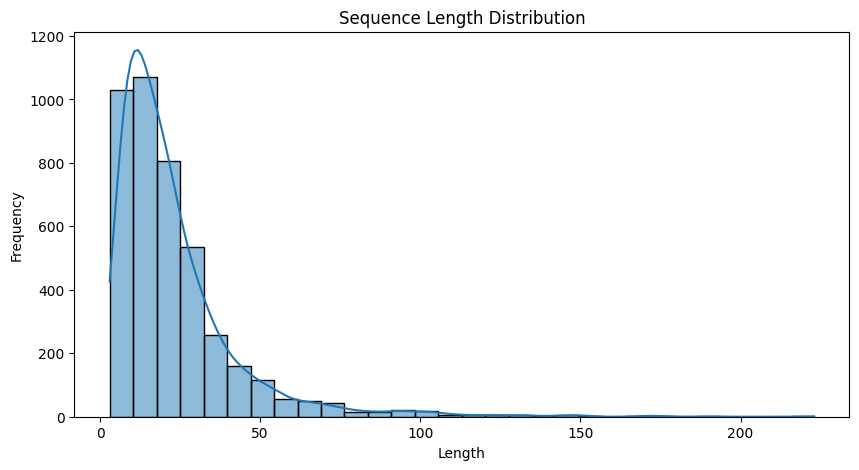

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test Tokenization
sample_text = train_df['text'].iloc[0]
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Original Text: {sample_text}")
print(f"Tokens       : {tokens}")
print(f"Token IDs    : {token_ids}")

# Visualize Sequence Length Distribution
lengths = train_df['text'].astype(str).apply(lambda x: len(tokenizer.encode(x)))
plt.figure(figsize=(10, 5))
sns.histplot(lengths, bins=30, kde=True)
plt.title("Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

## 4. Dataset & DataLoader

In [6]:
class EmotionDataset(Dataset):
    def __init__(self, reviews, labels, tokenizer, max_len):
        self.reviews = reviews
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, item):
        review = str(self.reviews[item])
        label = int(self.labels[item])

        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def create_data_loader(df, tokenizer, max_len, batch_size, shuffle=True):
    ds = EmotionDataset(
        reviews=df['text'].to_numpy(),
        labels=df['label'].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test data loader is global
test_data_loader = create_data_loader(test_df, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=False)

## 5. Full Fine-Tuning IndoBERT Initialization
Memuat pre-trained model dan memastikan seluruh parameter bersifat trainable.

In [7]:
def initialize_model(model_name, num_labels, dropout_prob, freeze_layers=6):
    model = BertForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    # Set custom classification dropout
    model.config.classifier_dropout = dropout_prob

    # Freeze the bottom N encoder layers to prevent overfitting
    if freeze_layers > 0:
        print(f"Freezing embeddings and bottom {freeze_layers} encoder layers...")
        for param in model.bert.embeddings.parameters():
            param.requires_grad = False
        for layer_idx in range(freeze_layers):
            for param in model.bert.encoder.layer[layer_idx].parameters():
                param.requires_grad = False

    model = model.to(DEVICE)
    return model

model = initialize_model(MODEL_NAME, NUM_LABELS, CLASSIFIER_DROPOUT, FREEZE_LAYERS)

# Verify parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Freezing embeddings and bottom 6 encoder layers...
Total Parameters    : 124,442,882
Trainable Parameters: 43,119,362


## 6. Training Configuration & Loop

In [8]:
# Standard CrossEntropyLoss with Label Smoothing (no class weights)
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING).to(DEVICE)

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
    }

def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Training")
    for d in progress_bar:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        _, preds = torch.max(logits, dim=1)
        loss = loss_fn(logits, labels)

        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        progress_bar.set_postfix({'loss': np.mean(losses)})

    metrics = compute_metrics(all_labels, all_preds)
    return correct_predictions.double() / n_examples, np.mean(losses), metrics

def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)
            loss = loss_fn(logits, labels)

            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    metrics = compute_metrics(all_labels, all_preds)
    return correct_predictions.double() / n_examples, np.mean(losses), metrics, all_labels, all_preds

## 7. Execution: Training Loop

In [9]:
def train_cross_validation(learning_rate):
    print(f"==================================================")
    print(f"STARTING 5-FOLD CROSS VALIDATION WITH LR = {learning_rate}")
    print(f"==================================================")

    cv_history = []
    start_time = time.time()

    for fold_idx in range(5):
        print(f"\n--- Fold {fold_idx + 1} / 5 ---")

        # Split train and validation dynamically based on fold column
        fold_train_df = train_df[train_df['fold'] != fold_idx].reset_index(drop=True)
        fold_val_df = train_df[train_df['fold'] == fold_idx].reset_index(drop=True)

        fold_train_loader = create_data_loader(fold_train_df, tokenizer, MAX_LEN, BATCH_SIZE)
        fold_val_loader = create_data_loader(fold_val_df, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=False)

        # Initialize model, optimizer, scheduler for this fold
        fold_model = initialize_model(MODEL_NAME, NUM_LABELS, CLASSIFIER_DROPOUT, FREEZE_LAYERS)
        fold_optimizer = AdamW(fold_model.parameters(), lr=learning_rate, weight_decay=WEIGHT_DECAY)

        total_steps = len(fold_train_loader) * EPOCHS
        warmup_steps = max(1, int(total_steps * WARMUP_RATIO))
        fold_scheduler = get_linear_schedule_with_warmup(
            fold_optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )

        best_val_loss = float('inf')
        patience_counter = 0
        fold_best_path = f"{OUTPUT_DIR}/model/best_model_fold_{fold_idx}.bin"

        fold_history = {
            'epoch': [],
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': []
        }

        for epoch in range(EPOCHS):
            print(f"Epoch {epoch + 1}/{EPOCHS}")

            # Train epoch
            train_acc, train_loss, train_metrics = train_epoch(
                fold_model, fold_train_loader, loss_fn, fold_optimizer, DEVICE, fold_scheduler, len(fold_train_df)
            )

            # Val epoch
            val_acc, val_loss, val_metrics, _, _ = eval_model(
                fold_model, fold_val_loader, loss_fn, DEVICE, len(fold_val_df)
            )

            print(
                f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
                f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
                f"Best Val Loss: {best_val_loss:.4f} | Patience: {patience_counter}/{PATIENCE}"
            )

            fold_history['epoch'].append(epoch + 1)
            fold_history['train_loss'].append(train_loss)
            fold_history['train_acc'].append(train_acc.item())
            fold_history['val_loss'].append(val_loss)
            fold_history['val_acc'].append(val_acc.item())

            # Early stopping monitors val_loss
            if val_loss < best_val_loss:
                torch.save(fold_model.state_dict(), fold_best_path)
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= PATIENCE:
                print(f"Early stopping triggered for Fold {fold_idx + 1} at epoch {epoch + 1}.")
                break

        cv_history.append(fold_history)

    end_time = time.time()
    print(f"\nCross-validation completed in {(end_time - start_time)/60:.2f} minutes.")

    # Save history as JSON file
    history_json_path = f"{OUTPUT_DIR}/reports/training_history.json"
    with open(history_json_path, 'w') as f:
        json.dump(cv_history, f, indent=2)
    print(f"Saved cross-validation training history to: {history_json_path}")

    return cv_history

# Execute 5-fold cross validation for the selected learning rate
cv_results = train_cross_validation(SELECTED_LR)

STARTING 5-FOLD CROSS VALIDATION WITH LR = 2e-05

--- Fold 1 / 5 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Freezing embeddings and bottom 6 encoder layers...
Epoch 1/10


Training:   0%|          | 0/212 [00:00<?, ?it/s]

...

Train loss: 0.2232 acc: 0.9882 | Val loss: 0.2461 acc: 0.9775 | Best Val Loss: 0.2432 | Patience: 0/3
Epoch 4/10


Training:   0%|          | 0/212 [00:00<?, ?it/s]

Train loss: 0.2145 acc: 0.9920 | Val loss: 0.2655 acc: 0.9692 | Best Val Loss: 0.2432 | Patience: 1/3
Epoch 5/10


Training:   0%|          | 0/212 [00:00<?, ?it/s]

Train loss: 0.2102 acc: 0.9950 | Val loss: 0.2552 acc: 0.9728 | Best Val Loss: 0.2432 | Patience: 2/3
Early stopping triggered for Fold 5 at epoch 5.

Cross-validation completed in 32.85 minutes.
Saved cross-validation training history to: /content/drive/MyDrive/xai_lime_vs_shap/outputs/finetuning_indobert/reports/training_history.json


## 8. Evaluation & Visualization

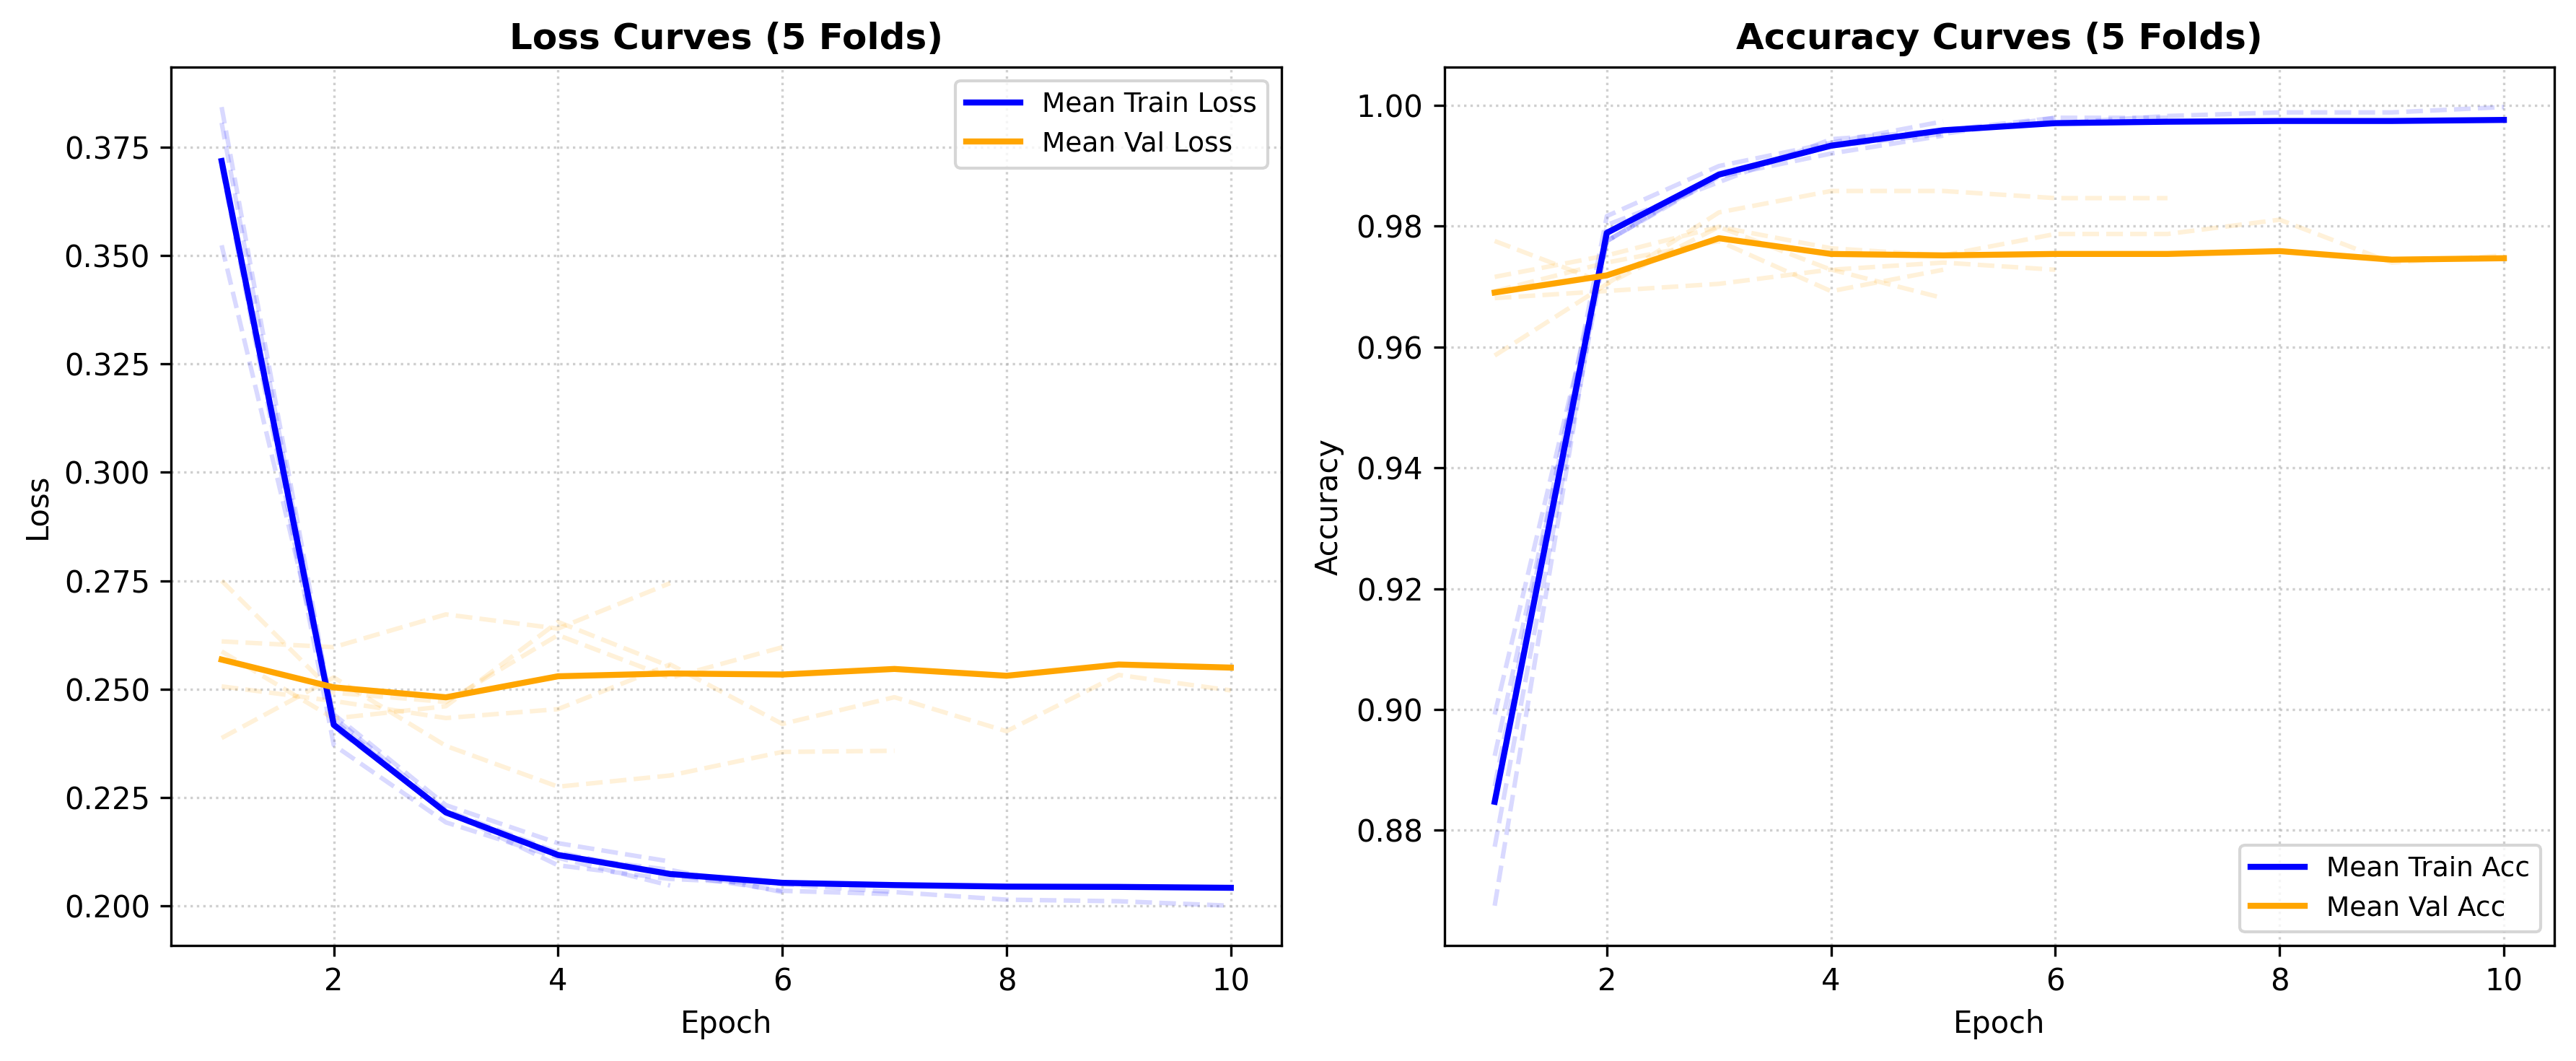

Evaluating 5-fold ensemble model on the test set...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Freezing embeddings and bottom 6 encoder layers...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Freezing embeddings and bottom 6 encoder layers...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Freezing embeddings and bottom 6 encoder layers...

TABEL HASIL MODEL UNTUK LAPORAN SKRIPSI

### TABEL 4: TEXT CLASSIFICATION REPORT (ENSEMBLE MODEL ON TEST SET)
              precision    recall  f1-score   support

    negative     0.9801    0.9854    0.9827       549
    positive     0.9842    0.9783    0.9812       508

    accuracy                         0.9820      1057
   macro avg     0.9821    0.9819    0.9820      1057
weighted avg     0.9820    0.9820    0.9820      1057

|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| negative     |      0.9801 |   0.9854 |     0.9827 |   549     |
| positive     |      0.9842 |   0.9783 |     0.9812 |   508     |
| accuracy     |      0.982  |   0.982  |     0.982  |     0.982 |
| macro avg    |      0.9821 |   0.9819 |     0.982  |  1057     |
| weighted avg |      0.982  |   0.982  |     0.982  |  1057     |

### TABEL 5: CONFUSION MATRIX (RAW COUNTS

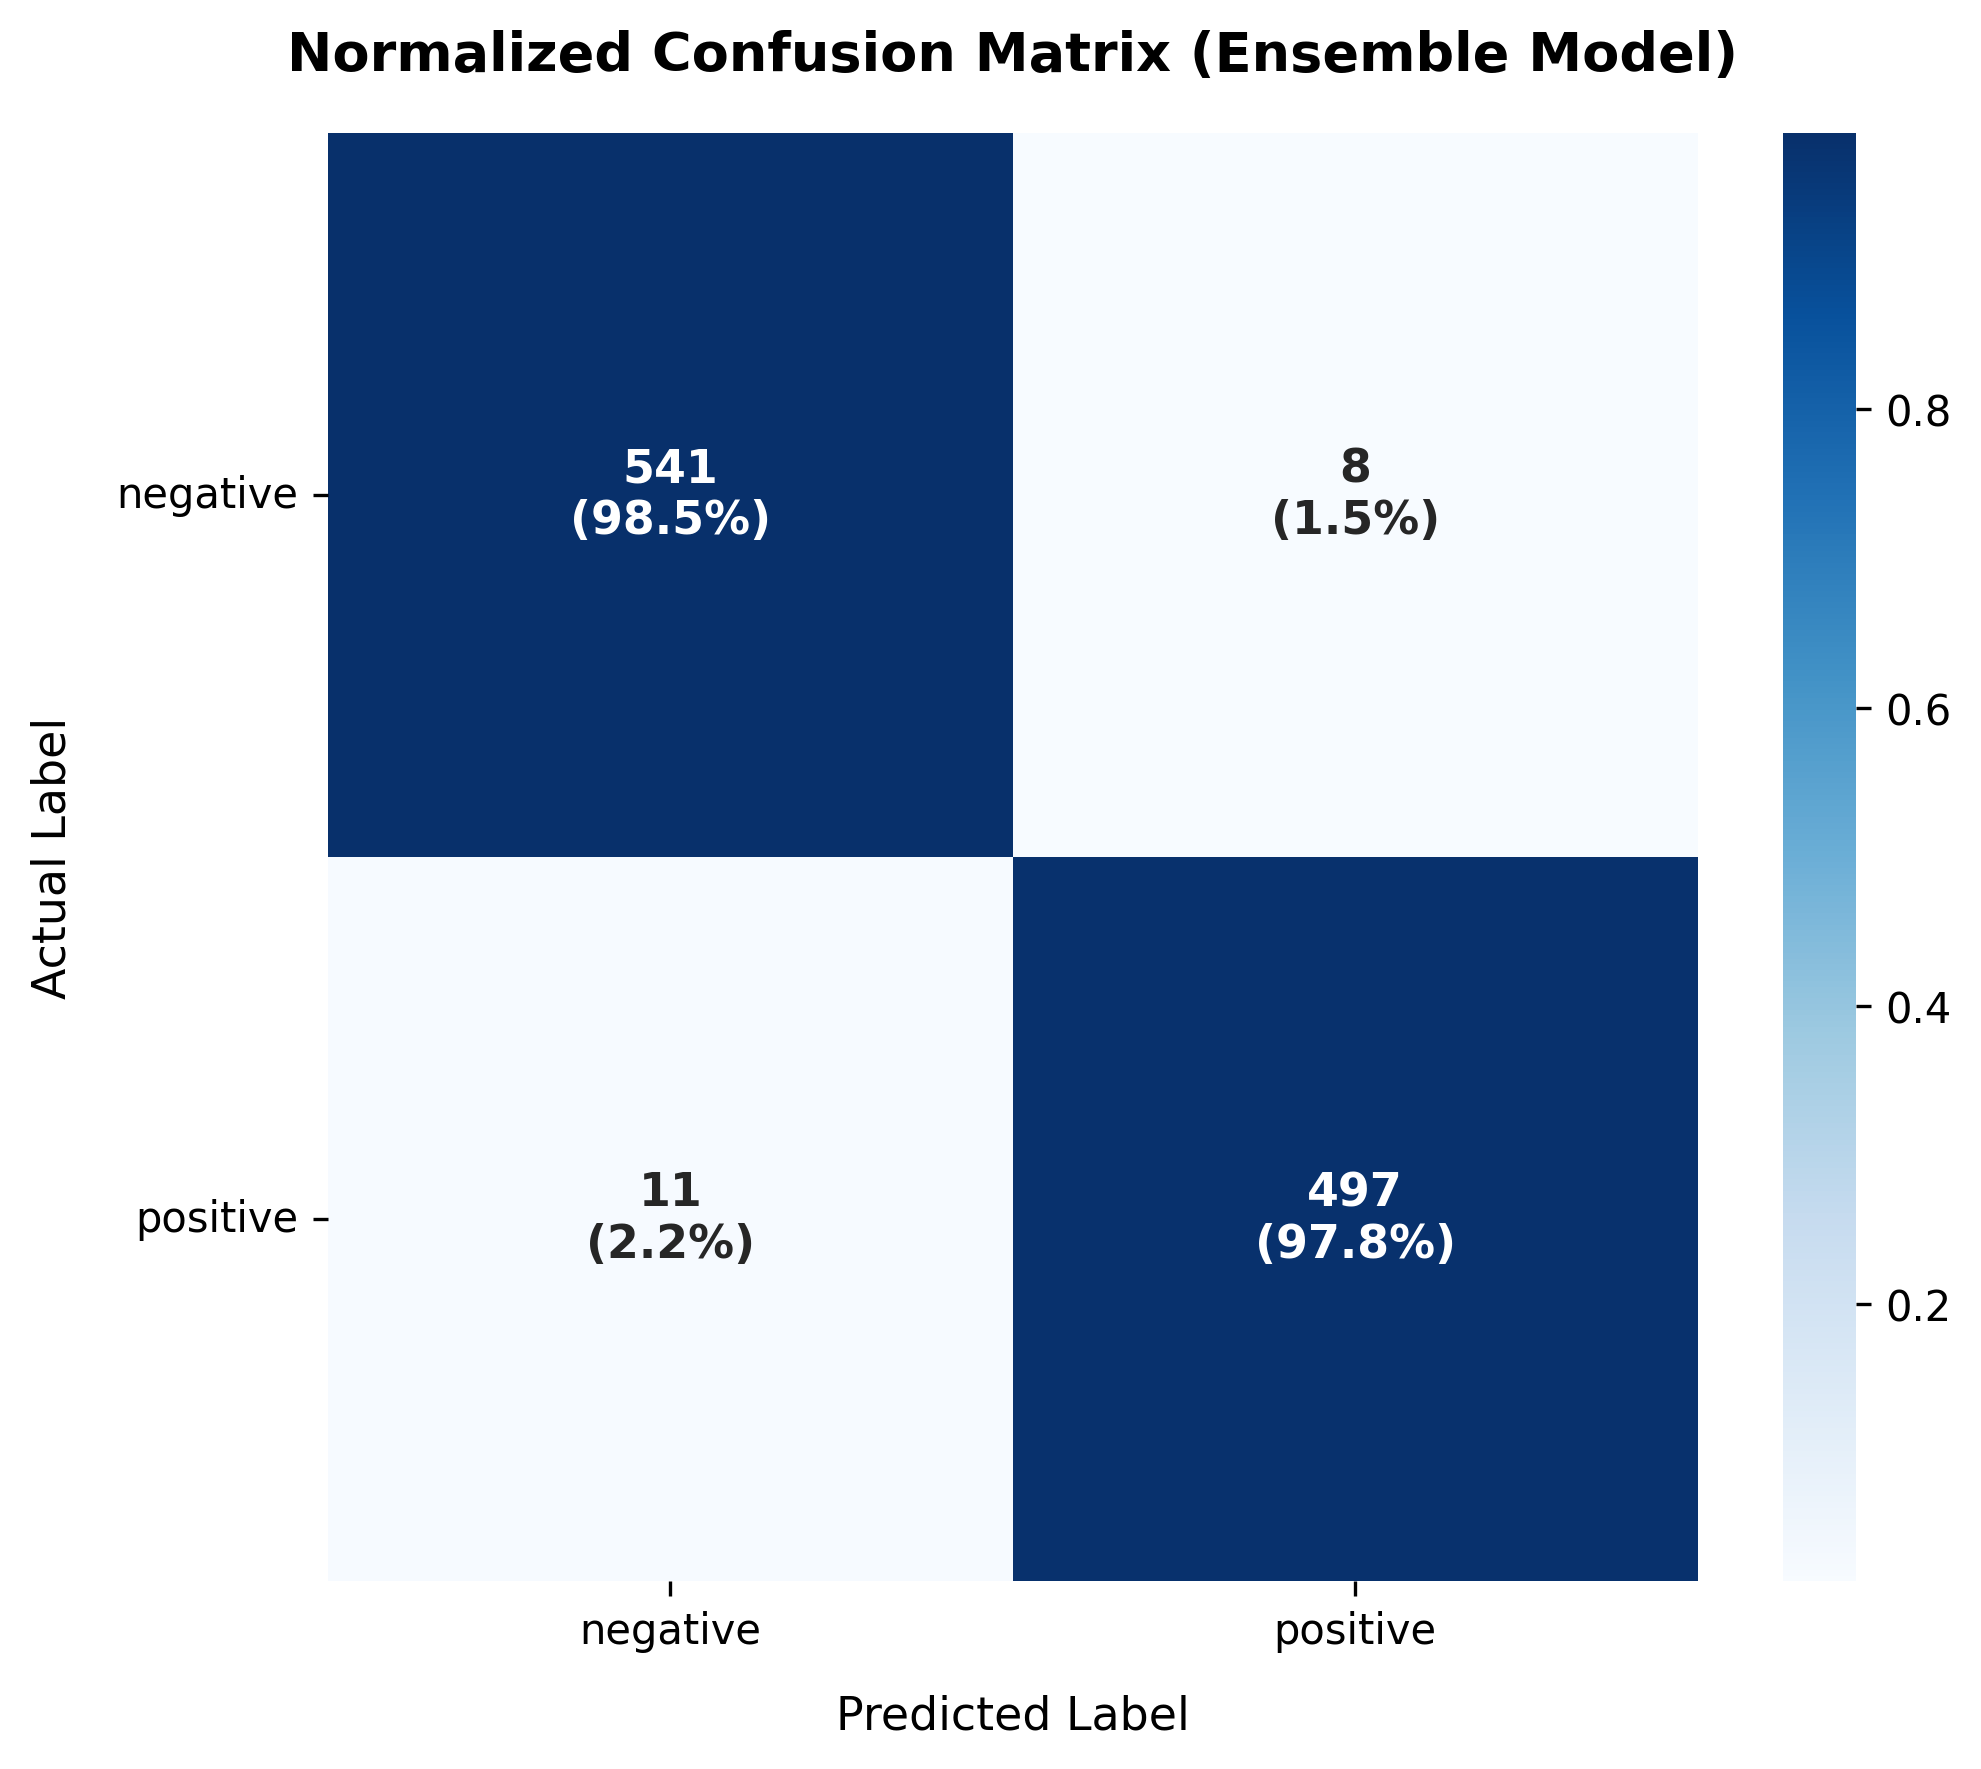


Ensemble Test evaluation completed.
Accuracy      : 0.9820
Macro Precision: 0.9821
Macro Recall   : 0.9819
Macro F1       : 0.9820
Weighted F1    : 0.9820


In [10]:
# --- ACADEMIC VISUALIZATION: LOSS & ACCURACY CURVES ---
max_epochs = max(len(fh['epoch']) for fh in cv_results)
epochs_range = list(range(1, max_epochs + 1))

# Align fold histories for averaging (pad with final epoch values in case of early stopping)
aligned_train_losses = []
aligned_val_losses = []
aligned_train_accs = []
aligned_val_accs = []

for fh in cv_results:
    t_loss = fh['train_loss'] + [fh['train_loss'][-1]] * (max_epochs - len(fh['train_loss']))
    v_loss = fh['val_loss'] + [fh['val_loss'][-1]] * (max_epochs - len(fh['val_loss']))
    t_acc  = fh['train_acc'] + [fh['train_acc'][-1]] * (max_epochs - len(fh['train_acc']))
    v_acc  = fh['val_acc'] + [fh['val_acc'][-1]] * (max_epochs - len(fh['val_acc']))
    aligned_train_losses.append(t_loss)
    aligned_val_losses.append(v_loss)
    aligned_train_accs.append(t_acc)
    aligned_val_accs.append(v_acc)

mean_train_loss = np.mean(aligned_train_losses, axis=0)
mean_val_loss   = np.mean(aligned_val_losses, axis=0)
mean_train_acc  = np.mean(aligned_train_accs, axis=0)
mean_val_acc    = np.mean(aligned_val_accs, axis=0)

plt.figure(figsize=(12, 5), dpi=300)

# Plot Loss
plt.subplot(1, 2, 1)
for i, fh in enumerate(cv_results):
    plt.plot(fh['epoch'], fh['train_loss'], color='blue', alpha=0.15, linestyle='--')
    plt.plot(fh['epoch'], fh['val_loss'], color='orange', alpha=0.15, linestyle='--')
plt.plot(epochs_range, mean_train_loss, color='blue', label='Mean Train Loss', linewidth=2)
plt.plot(epochs_range, mean_val_loss, color='orange', label='Mean Val Loss', linewidth=2)
plt.title('Loss Curves (5 Folds)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, fontsize=9)

# Plot Accuracy
plt.subplot(1, 2, 2)
for i, fh in enumerate(cv_results):
    plt.plot(fh['epoch'], fh['train_acc'], color='blue', alpha=0.15, linestyle='--')
    plt.plot(fh['epoch'], fh['val_acc'], color='orange', alpha=0.15, linestyle='--')
plt.plot(epochs_range, mean_train_acc, color='blue', label='Mean Train Acc', linewidth=2)
plt.plot(epochs_range, mean_val_acc, color='orange', label='Mean Val Acc', linewidth=2)
plt.title('Accuracy Curves (5 Folds)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/training_curves.png", bbox_inches='tight')
plt.show()

def get_predictions(model, data_loader):
    model = model.eval()
    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:
            texts = d["review_text"]
            input_ids = d["input_ids"].to(DEVICE)
            attention_mask = d["attention_mask"].to(DEVICE)
            labels = d["labels"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=1)
            _, preds = torch.max(logits, dim=1)

            review_texts.extend(texts)
            predictions.extend(preds.detach().cpu().tolist())
            prediction_probs.extend(probs.detach().cpu().tolist())
            real_values.extend(labels.detach().cpu().tolist())

    predictions = torch.tensor(predictions)
    prediction_probs = torch.tensor(prediction_probs)
    real_values = torch.tensor(real_values)
    return review_texts, predictions, prediction_probs, real_values

# Final Evaluation on Test Set uses the ensemble of all 5 folds
print("Evaluating 5-fold ensemble model on the test set...")
y_pred_probs_list = []
y_test_check = None
y_review_texts = None

for fold_idx in range(5):
    fold_model_path = f"{OUTPUT_DIR}/model/best_model_fold_{fold_idx}.bin"
    fold_model = initialize_model(MODEL_NAME, NUM_LABELS, CLASSIFIER_DROPOUT, FREEZE_LAYERS)
    fold_model.load_state_dict(torch.load(fold_model_path, map_location=DEVICE))

    review_texts, y_pred_fold, y_pred_probs_fold, y_test_fold = get_predictions(fold_model, test_data_loader)
    y_pred_probs_list.append(y_pred_probs_fold)
    y_test_check = y_test_fold
    y_review_texts = review_texts

# Average probabilities across the 5 folds (Ensemble prediction)
y_pred_probs = torch.mean(torch.stack(y_pred_probs_list), dim=0)
y_pred = torch.argmax(y_pred_probs, dim=1)
y_test = y_test_check

print("\n" + "="*60 + "\nTABEL HASIL MODEL UNTUK LAPORAN SKRIPSI\n" + "="*60)

# --- TABEL 4: Classification Report Table ---
class_names = [ID2EMOTION[i] for i in range(NUM_LABELS)]
report = classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0)
print("\n### TABEL 4: TEXT CLASSIFICATION REPORT (ENSEMBLE MODEL ON TEST SET)")
print(report)

report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
report_df = report_df.round(4)
print(report_df.to_markdown())

pd.DataFrame(report_dict).T.to_csv(f"{OUTPUT_DIR}/reports/classification_report.csv")
with open(f"{OUTPUT_DIR}/reports/classification_report.txt", "w") as f:
    f.write(report)

# --- TABEL 5: Confusion Matrix Table & Heatmap ---
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\n### TABEL 5: CONFUSION MATRIX (RAW COUNTS)")
print(df_cm.to_markdown())

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(7, 6), dpi=300)
annot_labels = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot_labels[i, j] = f"{cm[i, j]}\n({cm_normalized[i, j]*100:.1f}%)"

sns.heatmap(
    cm_normalized,
    annot=annot_labels,
    fmt='',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 11, "weight": "bold"},
    cbar=True
)
plt.title("Normalized Confusion Matrix (Ensemble Model)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Predicted Label", fontsize=11, labelpad=10)
plt.ylabel("Actual Label", fontsize=11, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/confusion_matrix.png", bbox_inches='tight')
plt.show()

final_acc = accuracy_score(y_test, y_pred)
final_macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
final_macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
final_macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
final_weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

final_metrics = {
    'test_accuracy': final_acc,
    'test_macro_precision': final_macro_precision,
    'test_macro_recall': final_macro_recall,
    'test_macro_f1': final_macro_f1,
    'test_weighted_f1': final_weighted_f1,
}
with open(f"{OUTPUT_DIR}/reports/test_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print("\n" + "="*60)
print('Ensemble Test evaluation completed.')
print(f"Accuracy      : {final_acc:.4f}")
print(f"Macro Precision: {final_macro_precision:.4f}")
print(f"Macro Recall   : {final_macro_recall:.4f}")
print(f"Macro F1       : {final_macro_f1:.4f}")
print(f"Weighted F1    : {final_weighted_f1:.4f}")
print("="*60)

## 9. Error Analysis
Menganalisis sampel yang diprediksi salah untuk memahami pola misklasifikasi model.

In [11]:
error_df = pd.DataFrame({
    'review_text': y_review_texts,
    'true_labels': y_test.tolist(),
    'pred_labels': y_pred.tolist(),
    'confidence': [probs[pred].item() for probs, pred in zip(y_pred_probs, y_pred)]
})

# Filter only errors
errors = error_df[error_df['true_labels'] != error_df['pred_labels']].copy()

# Map back to names
errors['true_emotion'] = errors['true_labels'].map(ID2EMOTION)
errors['pred_emotion'] = errors['pred_labels'].map(ID2EMOTION)

print("\n" + "="*60 + "\nANALISIS KESALAHAN (ERROR ANALYSIS) UNTUK LAPORAN SKRIPSI\n" + "="*60)

# --- TABEL 6: Top 10 High-Confidence Errors ---
print("\n### TABEL 6: CONTOH 10 KASUS SALAH KLASIFIKASI DENGAN CONFIDENCE TINGGI")
display_df = errors.sort_values(by='confidence', ascending=False).head(10)
print(display_df[['review_text', 'true_emotion', 'pred_emotion', 'confidence']].to_markdown(index=False))
print("-" * 60)

# --- TABEL 7: Misclassification Pattern ---
error_pattern = errors.groupby(['true_emotion', 'pred_emotion']).size().reset_index(name='count')
error_pattern = error_pattern.sort_values(by='count', ascending=False)
print("\n### TABEL 7: POLA SALAH KLASIFIKASI (ERROR PATTERNS)")
print(error_pattern.to_markdown(index=False))
print("="*60)

# Ensure the reports directory exists before saving
os.makedirs(f"{OUTPUT_DIR}/reports", exist_ok=True)

# Save Error Report
errors.to_csv(f"{OUTPUT_DIR}/reports/error_analysis.csv", index=False)


ANALISIS KESALAHAN (ERROR ANALYSIS) UNTUK LAPORAN SKRIPSI

### TABEL 6: CONTOH 10 KASUS SALAH KLASIFIKASI DENGAN CONFIDENCE TINGGI
| review_text                                                                                                                                                                                                                                                     | true_emotion   | pred_emotion   |   confidence |
|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:---------------|:---------------|-------------:|
| beli 2 beda warna, tapi sama sis nya dikirim warna yang sama. udah terlanjur dipack sama sis nya, diganti ovo lho ke saya. padahal saya terima 2 barang. tanggung jawab sekalii. celana sesuai deskripsi.                                               

## 10. Save Model & Tokenizer

In [12]:
# Save Final Model and Tokenizer
model.save_pretrained(f"{OUTPUT_DIR}/model/final_indobert_sentiment")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/tokenizer/indobert_tokenizer")

# Determine the best model path from cross-validation results
overall_best_val_loss = float('inf')
best_fold_idx = -1

for idx, fold_history in enumerate(cv_results):
    # Find the minimum validation loss achieved in this specific fold
    min_val_loss_in_fold = min(fold_history['val_loss'])
    if min_val_loss_in_fold < overall_best_val_loss:
        overall_best_val_loss = min_val_loss_in_fold
        best_fold_idx = idx

best_model_path = f"{OUTPUT_DIR}/model/best_model_fold_{best_fold_idx}.bin"
shutil.copy2(best_model_path, f"{OUTPUT_DIR}/model/best_model.bin")

# Copy the best fold parameters as the final model binary for inference
shutil.copy2(best_model_path, f"{OUTPUT_DIR}/model/final_indobert_sentiment/pytorch_model.bin")

# Save Training History
with open(f"{OUTPUT_DIR}/reports/training_history.json", "w") as f:
    json.dump(cv_results, f, indent=2)

print(f"All assets saved to: {OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All assets saved to: /content/drive/MyDrive/xai_lime_vs_shap/outputs/finetuning_indobert


## 11. Experiment Summary

In [13]:
# Compile learning rate tuning experiments dynamically (plan for grid search)
print("=== LEARNING RATE GRID SEARCH EXPERIMENT PLAN ===")
print(f"Target Learning Rates: {LR_EXPERIMENTS}")
print(f"Selected Base LR     : {SELECTED_LR}")
print(f"Weight Decay         : {WEIGHT_DECAY}")
print(f"Classifier Dropout   : {CLASSIFIER_DROPOUT}")
print(f"Label Smoothing      : {LABEL_SMOOTHING}")
print(f"Model Name           : {MODEL_NAME}")
print(f"Random Seed          : {RANDOM_STATE}")
print(f"Timestamp            : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# To execute a learning rate experiment, you can loop over LR_EXPERIMENTS and run train_cross_validation(lr)
print("\n--- Running full tuning experiments (uncomment to execute) ---")
# lr_results = {}
# for lr in LR_EXPERIMENTS:
#     hist = train_cross_validation(lr)
#     # Predict test ensemble accuracy
#     # (Save fold weights to fold_{k}_lr_{lr}.bin)


=== LEARNING RATE GRID SEARCH EXPERIMENT PLAN ===
Target Learning Rates: [5e-06, 1e-05, 2e-05, 3e-05]
Selected Base LR     : 2e-05
Weight Decay         : 0.02
Classifier Dropout   : 0.3
Label Smoothing      : 0.1
Model Name           : indobenchmark/indobert-base-p2
Random Seed          : 42
Timestamp            : 2026-06-03 18:02:12

--- Running full tuning experiments (uncomment to execute) ---
